# 01 - Training Smoke Run And TensorBoard

Goal: prove the training stack works before spending hours on final runs. This notebook runs a small PPO job, records Ray/TensorBoard logs, reads `progress.csv`, and shows how checkpoint resume works.

In [1]:
from pathlib import Path
import sys

def _add_project_root_to_path():
    for base in (Path.cwd(), *Path.cwd().parents):
        for candidate in (base, base / "soccer-twos-starter"):
            if (candidate / "soccer_twos_project" / "notebook_tools.py").exists():
                if str(candidate) not in sys.path:
                    sys.path.insert(0, str(candidate))
                return candidate
    raise FileNotFoundError("Could not find the soccer-twos-starter project root.")

_add_project_root_to_path()

import importlib
import soccer_twos_project.notebook_tools as notebook_tools
importlib.reload(notebook_tools)
from soccer_twos_project.notebook_tools import *

ctx = setup_project()
show_hardware()

Project root: /Users/vedaangchopra/all_data/Georgia Tech/Course Content/CS 8803- DRL/project/soccer-twos-starter
Artifact root: /Users/vedaangchopra/all_data/Georgia Tech/Course Content/CS 8803- DRL/project/soccer-twos-starter/artifacts/cs8803_soccer_twos
Python: /opt/homebrew/Caskroom/miniconda/base/envs/soccertwos/bin/python
soccer_twos: /opt/homebrew/Caskroom/miniconda/base/envs/soccertwos/lib/python3.8/site-packages/soccer_twos/__init__.py
ray: 1.13.0
torch: 1.13.1
python: /opt/homebrew/Caskroom/miniconda/base/envs/soccertwos/bin/python
{
  "cpu_count": 16,
  "gpu_name": "",
  "mlx_available": false,
  "ram_gb": 64.0,
  "torch_cuda_available": false,
  "torch_mps_available": true
}


## Start TensorBoard

Use the inline TensorBoard magic in Jupyter, or use the process launcher and open `http://localhost:6006`.

In [2]:
print("TensorBoard logdir:", ctx.dirs["checkpoints"])
%reload_ext tensorboard
%tensorboard --logdir ./artifacts/cs8803_soccer_twos/checkpoints --reload_interval 10

TensorBoard logdir: /Users/vedaangchopra/all_data/Georgia Tech/Course Content/CS 8803- DRL/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints


In [3]:
# Alternative browser launcher if the magic is not enough:
# tensorboard_proc = launch_tensorboard(ctx, port=6006)

## Run The Smoke Job

This is intentionally short. It should create a checkpoint, an event file, `progress.csv`, and valid `run_metadata.json`.

In [4]:
SMOKE_TIMESTEPS = 25_000
smoke_checkpoint = run_training(
    ctx,
    stage="ppo_baseline",
    profile_name="auto",
    timesteps=SMOKE_TIMESTEPS,
    smoke=True,
    verbose=1,
)
smoke_checkpoint

2026-04-22 00:15:47,038	INFO tune.py:747 -- Total run time: 188.26 seconds (186.91 seconds for the tuning loop).
I0000 00:00:1776831350.072540  204522 fork_posix.cc:75] Other threads are currently calling into gRPC, skipping fork() handlers


Best trial: PPO_Soccer_80072_00000
Best checkpoint: /Users/vedaangchopra/all_data/Georgia Tech/Course Content/CS 8803- DRL/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_baseline/PPO_Soccer_80072_00000_0_2026-04-22_00-12-39/checkpoint_000025/checkpoint-25
Wrote run metadata: /Users/vedaangchopra/all_data/Georgia Tech/Course Content/CS 8803- DRL/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_baseline/run_metadata.json
Returned checkpoint: /Users/vedaangchopra/all_data/Georgia Tech/Course Content/CS 8803- DRL/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_baseline/PPO_Soccer_80072_00000_0_2026-04-22_00-12-39/checkpoint_000025/checkpoint-25


'/Users/vedaangchopra/all_data/Georgia Tech/Course Content/CS 8803- DRL/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_baseline/PPO_Soccer_80072_00000_0_2026-04-22_00-12-39/checkpoint_000025/checkpoint-25'

## Inspect Progress

For early smoke runs, reward can still be flat. The point here is to verify logging, checkpoints, and metadata.

In [5]:
show_progress(ctx, "ppo_baseline", rows=10)

Latest progress file: /Users/vedaangchopra/all_data/Georgia Tech/Course Content/CS 8803- DRL/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_baseline/PPO_Soccer_80072_00000_0_2026-04-22_00-12-39/progress.csv


,training_iteration,timesteps_total,episodes_total,episode_reward_mean,episode_reward_min,episode_reward_max,time_total_s
15,16,16000,16,-0.125000,-2.0,0.0000,116.348845
16,17,17000,17,-0.117647,-2.0,0.0000,123.609998
17,18,18000,18,-0.111111,-2.0,0.0000,130.998629
18,19,19000,19,-0.105263,-2.0,0.0000,138.349448
19,20,20000,20,-0.071760,-2.0,0.5648,145.671480
20,21,21000,21,-0.068343,-2.0,0.5648,153.447860
21,22,22000,22,-0.065236,-2.0,0.5648,160.710643
22,23,23000,23,-0.062400,-2.0,0.5648,168.319228
23,24,24000,24,-0.059800,-2.0,0.5648,175.534313
24,25,25000,25,-0.057408,-2.0,0.5648,182.804810


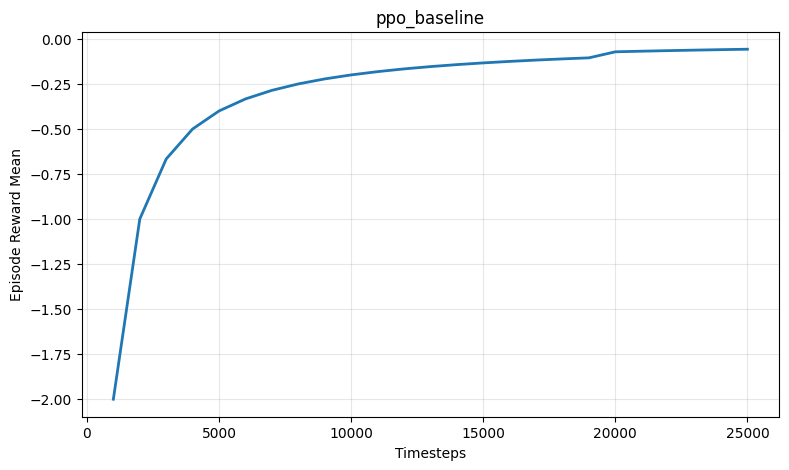

{
  "algo": "PPO",
  "best_checkpoint": "/Users/vedaangchopra/all_data/Georgia Tech/Course Content/CS 8803- DRL/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_baseline/PPO_Soccer_80072_00000_0_2026-04-22_00-12-39/checkpoint_000025/checkpoint-25",
  "criterion": "policy performance baseline",
  "stage": "ppo_baseline",
  "stop": {
    "time_total_s": 1800,
    "timesteps_total": 25000
  }
}


{'algo': 'PPO',
 'best_checkpoint': '/Users/vedaangchopra/all_data/Georgia Tech/Course Content/CS 8803- DRL/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_baseline/PPO_Soccer_80072_00000_0_2026-04-22_00-12-39/checkpoint_000025/checkpoint-25',
 'best_trial': 'PPO_Soccer_80072_00000',
 'config': {'env': 'Soccer',
  'env_config': {'flatten_branched': True,
   'multiagent': False,
   'num_envs_per_worker': 1,
   'opponent_policy': '<function base_env_config.<locals>.<lambda> at 0x35825af70>',
   'render': False,
   'single_player': True,
   'variation': "<EnvType.team_vs_policy: 'team_vs_policy'>"},
  'framework': 'torch',
  'log_level': 'INFO',
  'model': {'fcnet_activation': 'relu',
   'fcnet_hiddens': [512],
   'vf_share_layers': True},
  'num_envs_per_worker': 1,
  'num_gpus': 0,
  'num_workers': 0,
  'rollout_fragment_length': 200,
  'train_batch_size': 1000},
 'criterion': 'policy performance baseline',
 'hardware': {'cpu_count': 16,
  'gpu_name': '',

In [6]:
plot_progress(ctx, "ppo_baseline")
run_metadata_status(ctx, "ppo_baseline")

## Resume Test

Uncomment this once the smoke checkpoint exists. Keep the resume test short.

In [7]:
# resumed_checkpoint = run_training(
#     ctx,
#     stage="ppo_baseline",
#     profile_name="auto",
#     timesteps=30_000,
#     smoke=True,
#     restore=smoke_checkpoint,
#     verbose=1,
# )
# resumed_checkpoint